<a href="https://colab.research.google.com/github/Daniel-Obuya/ATM-Project/blob/main/Verify_Mesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Connecting google colab notebook to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Proteus 8.6 SP2 Professional',
 'PDF Scanner 09-05-23 1.41.43 (1).pdf',
 'PDF Scanner 09-05-23 1.41.22.pdf',
 'PDF Scanner 09-05-23 12.48.32.pdf',
 'PDF Scanner 09-05-23 12.49.27.pdf',
 'PDF Scanner 09-05-23 12.45.50.pdf',
 'PDF Scanner 09-05-23 12.46.58.pdf',
 'PDF Scanner 09-05-23 1.41.43.pdf',
 'com.instapro.android Crash Report',
 'Sem 1',
 'Commitment letter.pdf',
 'Healthy eating in Kenya (1).docx',
 'Healthy eating in Kenya.docx',
 'Effective exercise routines (1).docx',
 'Effective exercise routines.docx',
 'Digital Logic Assignment ',
 "Daniel's_Professional Foundations_Folder",
 'Copy of ALX Professional Foundations - Skills Tracker.gsheet',
 'PEER COACHING REFLECTION.gdoc',
 'Copy of Google Workspace Skills Checklist_ PF.gsheet',
 'Copy of Asking the Right Questions - Practice Sheet - PF.gsheet',
 'Copy of Google Workspace Skills Checklist_ ALX Foundations.gsheet',
 'Copy of Project Plan Work plan Template_ALX (1).gsheet',
 'Copy of Project Plan Work plan Template_ALX .gsh

In [ ]:
# Checking for my VerifyMesh Dataset
os.listdir('/content/drive/MyDrive/Dataset')

['VerifyMesh_Initial_Competency_Dataset_V2.csv']

In [ ]:
#
import pandas as pd
file_path = '/content/drive/MyDrive/Dataset/VerifyMesh_Initial_Competency_Dataset_V2.csv'
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 12)


,agent_id,previous_experience_months,sales_experience_months,customer_service_experience_months,certification_count,relevant_certification,assessment_score,communication_score,product_knowledge_score,sales_skill_score,customer_service_score,competency_level
0,AGT00001,28,18,16,2,0,64,81,76,49,61,Needs Improvement
1,AGT00002,0,0,0,1,0,52,76,61,51,49,Basic
2,AGT00003,53,33,37,0,0,86,76,73,70,74,Advanced
3,AGT00004,53,53,36,2,1,72,67,56,87,67,Advanced
4,AGT00005,0,0,0,0,0,42,44,34,31,33,Needs Improvement


In [ ]:
print(df.columns.tolist())

['agent_id', 'previous_experience_months', 'sales_experience_months', 'customer_service_experience_months', 'certification_count', 'relevant_certification', 'assessment_score', 'communication_score', 'product_knowledge_score', 'sales_skill_score', 'customer_service_score', 'competency_level']


## Stage 1: Preprocessing

Creating the project directory structure in the Colab working directory to store models, processed data, and results. These directories are essential for organizing the project's outputs.

In [ ]:
import os

# Define the base project directory
project_dir = 'VerifyMesh_Colab'

# Define subdirectories
subdirs = [
    os.path.join(project_dir, 'data', 'processed'),
    os.path.join(project_dir, 'models'),
    os.path.join(project_dir, 'results')
]

# Create directories if they don't exist
for subdir in subdirs:
    os.makedirs(subdir, exist_ok=True)
    print(f'Created directory: {subdir}')

Created directory: VerifyMesh_Colab/data/processed
Created directory: VerifyMesh_Colab/models
Created directory: VerifyMesh_Colab/results



 Verifying the dataset properties as specified: shape, absence of null values, absence of duplicate agent IDs, correct columns, and the correct target distribution. The dataset has already been loaded into a DataFrame `df`.

In [ ]:
# Verify shape
expected_shape = (2000, 12)
actual_shape = df.shape
print(f"Dataset shape: {actual_shape} (Expected: {expected_shape})")
assert actual_shape == expected_shape, "Dataset shape mismatch!"

# Verify no nulls
null_counts = df.isnull().sum()
print("\nNull values per column:\n", null_counts[null_counts > 0])
assert null_counts.sum() == 0, "Null values found in the dataset!"

# Verify no duplicate agent IDs
duplicate_agent_ids = df['agent_id'].duplicated().sum()
print(f"\nNumber of duplicate agent IDs: {duplicate_agent_ids}")
assert duplicate_agent_ids == 0, "Duplicate agent IDs found!"

# Verify correct columns (already done in previous step, but re-confirming implicitly with below checks)
expected_columns = [
    'agent_id', 'previous_experience_months', 'sales_experience_months',
    'customer_service_experience_months', 'certification_count',
    'relevant_certification', 'assessment_score', 'communication_score',
    'product_knowledge_score', 'sales_skill_score',
    'customer_service_score', 'competency_level'
]
actual_columns = df.columns.tolist()
print(f"\nColumns in dataset: {actual_columns}")
assert sorted(actual_columns) == sorted(expected_columns), "Column mismatch!"

# Verify correct target distribution
expected_target_distribution = {
    'Needs Improvement': 300,
    'Basic': 600,
    'Competent': 700,
    'Advanced': 400
}
actual_target_distribution = df['competency_level'].value_counts().to_dict()
print(f"\nActual target distribution: {actual_target_distribution}")
for level, count in expected_target_distribution.items():
    assert actual_target_distribution.get(level) == count, f"Target distribution mismatch for {level}!"
print("Target distribution verified.")

Dataset shape: (2000, 12) (Expected: (2000, 12))

Null values per column:
 Series([], dtype: int64)

Number of duplicate agent IDs: 0

Columns in dataset: ['agent_id', 'previous_experience_months', 'sales_experience_months', 'customer_service_experience_months', 'certification_count', 'relevant_certification', 'assessment_score', 'communication_score', 'product_knowledge_score', 'sales_skill_score', 'customer_service_score', 'competency_level']

Actual target distribution: {'Competent': 700, 'Basic': 600, 'Advanced': 400, 'Needs Improvement': 300}
Target distribution verified.


 Performing the train-test split using `test_size=0.20`, `stratify=y`, and `random_state=42`. After splitting, I will verify the sizes and class distributions of the training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# The 'agent_id' column must not be used as a model feature
X = df.drop(columns=['agent_id', 'competency_level'])
y = df['competency_level']

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Verify training and testing set sizes
expected_train_size = 1600
expected_test_size = 400
print(f"\nTraining set size: {X_train.shape[0]} (Expected: {expected_train_size})")
print(f"Testing set size: {X_test.shape[0]} (Expected: {expected_test_size})")
assert X_train.shape[0] == expected_train_size, "Training set size mismatch!"
assert X_test.shape[0] == expected_test_size, "Testing set size mismatch!"

# Verify training class counts
expected_train_class_counts = {
    'Needs Improvement': 240,
    'Basic': 480,
    'Competent': 560,
    'Advanced': 320
}
actual_train_class_counts = y_train.value_counts().to_dict()
print(f"\nTraining class counts: {actual_train_class_counts}")
for level, count in expected_train_class_counts.items():
    assert actual_train_class_counts.get(level) == count, f"Training class count mismatch for {level}!"

# Verify testing class counts
expected_test_class_counts = {
    'Needs Improvement': 60,
    'Basic': 120,
    'Competent': 140,
    'Advanced': 80
}
actual_test_class_counts = y_test.value_counts().to_dict()
print(f"Testing class counts: {actual_test_class_counts}")
for level, count in expected_test_class_counts.items():
    assert actual_test_class_counts.get(level) == count, f"Testing class count mismatch for {level}!"

print("Train-test split and class distributions verified.")


Training set size: 1600 (Expected: 1600)
Testing set size: 400 (Expected: 400)

Training class counts: {'Competent': 560, 'Basic': 480, 'Advanced': 320, 'Needs Improvement': 240}
Testing class counts: {'Competent': 140, 'Basic': 120, 'Advanced': 80, 'Needs Improvement': 60}
Train-test split and class distributions verified.


## Stage 2 — Baseline Random Forest

Training a `RandomForestClassifier` using only the 10 raw features. The model will be configured with `n_estimators=100` and `random_state=42`. After training, the model will be saved as `models/baseline_random_forest.joblib`.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Define the 10 raw predictor features
raw_features = [
    'previous_experience_months',
    'sales_experience_months',
    'customer_service_experience_months',
    'certification_count',
    'relevant_certification',
    'assessment_score',
    'communication_score',
    'product_knowledge_score',
    'sales_skill_score',
    'customer_service_score'
]

# Prepare the training data with only raw features
X_train_raw = X_train[raw_features]

# Initialize the baseline Random Forest Classifier
baseline_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
baseline_rf_model.fit(X_train_raw, y_train)

# Save the model
model_path = 'VerifyMesh_Colab/models/baseline_random_forest.joblib'
joblib.dump(baseline_rf_model, model_path)
print(f"Baseline Random Forest model trained and saved to {model_path}")

Baseline Random Forest model trained and saved to VerifyMesh_Colab/models/baseline_random_forest.joblib


 Evaluating the baseline Random Forest model's performance on the locked test set (X_test, y_test) and compare it against the expected historical benchmarks. This evaluation includes Accuracy, Macro F1, Weighted F1, Macro Precision, and Macro Recall.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Prepare the test data with only raw features (X_test is locked)
X_test_raw = X_test[raw_features]

# Make predictions on the test set
y_pred_baseline = baseline_rf_model.predict(X_test_raw)

# Calculate metrics
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
macro_f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')
weighted_f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')
macro_precision_baseline = precision_score(y_test, y_pred_baseline, average='macro', zero_division=0)
macro_recall_baseline = recall_score(y_test, y_pred_baseline, average='macro')

print("Baseline Random Forest Test Performance:")
print(f"Accuracy = {accuracy_baseline:.4f}")
print(f"Macro F1 = {macro_f1_baseline:.4f}")
print(f"Weighted F1 = {weighted_f1_baseline:.4f}")
print(f"Macro Precision = {macro_precision_baseline:.4f}")
print(f"Macro Recall = {macro_recall_baseline:.4f}")

# Compare with expected historical test benchmark
expected_accuracy = 0.4925
expected_macro_f1 = 0.4880
expected_weighted_f1 = 0.4914
expected_macro_precision = 0.5178
expected_macro_recall = 0.4740

print("\nExpected Historical Test Benchmarks:")
print(f"Accuracy = {expected_accuracy}")
print(f"Macro F1 = {expected_macro_f1}")
print(f"Weighted F1 = {expected_weighted_f1}")
print(f"Macro Precision = {expected_macro_precision}")
print(f"Macro Recall = {expected_macro_recall}")

print("\nDeviation from Expected Benchmarks:")
print(f"Accuracy Deviation = {accuracy_baseline - expected_accuracy:.4f}")
print(f"Macro F1 Deviation = {macro_f1_baseline - expected_macro_f1:.4f}")
print(f"Weighted F1 Deviation = {weighted_f1_baseline - expected_weighted_f1:.4f}")
print(f"Macro Precision Deviation = {macro_precision_baseline - expected_macro_precision:.4f}")
print(f"Macro Recall Deviation = {macro_recall_baseline - expected_macro_recall:.4f}")

Baseline Random Forest Test Performance:
Accuracy = 0.4925
Macro F1 = 0.4880
Weighted F1 = 0.4914
Macro Precision = 0.5178
Macro Recall = 0.4740

Expected Historical Test Benchmarks:
Accuracy = 0.4925
Macro F1 = 0.488
Weighted F1 = 0.4914
Macro Precision = 0.5178
Macro Recall = 0.474

Deviation from Expected Benchmarks:
Accuracy Deviation = 0.0000
Macro F1 Deviation = -0.0000
Weighted F1 Deviation = 0.0000
Macro Precision Deviation = 0.0000
Macro Recall Deviation = -0.0000


## Stage 3A — Stratified 5-Fold Cross-Validation

Setting up stratified 5-fold cross-validation using `StratifiedKFold` and evaluate the baseline Random Forest model on the training data (`X_train_raw`, `y_train`).

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Configure StratifiedKFold
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define scoring metrics
scoring = ['accuracy', 'f1_macro', 'f1_weighted']

# Perform cross-validation on the baseline Random Forest model
cv_results_baseline = cross_validate(
    baseline_rf_model,
    X_train_raw,
    y_train,
    cv=stratified_kfold,
    scoring=scoring,
    return_train_score=False, # We are interested in validation scores
    n_jobs=-1 # Use all available cores
)

# Print mean and std of the cross-validation results
print("Baseline Random Forest 5-Fold Cross-Validation Results:")
mean_accuracy_cv = cv_results_baseline['test_accuracy'].mean()
std_accuracy_cv = cv_results_baseline['test_accuracy'].std()
print(f"Mean Accuracy = {mean_accuracy_cv:.4f} ± {std_accuracy_cv:.4f}")

mean_macro_f1_cv = cv_results_baseline['test_f1_macro'].mean()
std_macro_f1_cv = cv_results_baseline['test_f1_macro'].std()
print(f"Mean Macro F1 = {mean_macro_f1_cv:.4f} ± {std_macro_f1_cv:.4f}")

mean_weighted_f1_cv = cv_results_baseline['test_f1_weighted'].mean()
std_weighted_f1_cv = cv_results_baseline['test_f1_weighted'].std()
print(f"Mean Weighted F1 = {mean_weighted_f1_cv:.4f} ± {std_weighted_f1_cv:.4f}")

# Compare with expected values
expected_mean_accuracy = 0.4894
expected_std_accuracy = 0.0246
expected_mean_macro_f1 = 0.4769
expected_std_macro_f1 = 0.0311
expected_mean_weighted_f1 = 0.4859
expected_std_weighted_f1 = 0.0256

print("\nExpected 5-Fold Cross-Validation Benchmarks:")
print(f"Mean Accuracy ≈ {expected_mean_accuracy} ± {expected_std_accuracy}")
print(f"Mean Macro F1 ≈ {expected_mean_macro_f1} ± {expected_std_macro_f1}")
print(f"Mean Weighted F1 ≈ {expected_mean_weighted_f1} ± {expected_std_weighted_f1}")

print("\nDeviation from Expected CV Benchmarks:")
print(f"Accuracy Mean Deviation = {mean_accuracy_cv - expected_mean_accuracy:.4f}")
print(f"Macro F1 Mean Deviation = {mean_macro_f1_cv - expected_mean_macro_f1:.4f}")
print(f"Weighted F1 Mean Deviation = {mean_weighted_f1_cv - expected_mean_weighted_f1:.4f}")

Baseline Random Forest 5-Fold Cross-Validation Results:
Mean Accuracy = 0.4894 ± 0.0246
Mean Macro F1 = 0.4769 ± 0.0311
Mean Weighted F1 = 0.4859 ± 0.0256

Expected 5-Fold Cross-Validation Benchmarks:
Mean Accuracy ≈ 0.4894 ± 0.0246
Mean Macro F1 ≈ 0.4769 ± 0.0311
Mean Weighted F1 ≈ 0.4859 ± 0.0256

Deviation from Expected CV Benchmarks:
Accuracy Mean Deviation = -0.0000
Macro F1 Mean Deviation = 0.0000
Weighted F1 Mean Deviation = -0.0000


## Stage 3C — Feature Engineering

Creating the five specified engineered features by applying the given formulas to the `X_train` DataFrame. These features are `total_domain_experience`, `average_skill_score`, `composite_eval_index`, `skill_consistency`, and `certified_leverage`.

In [ ]:
# Create a copy of X_train to add engineered features
X_train_engineered = X_train_raw.copy()

# 1. total_domain_experience
X_train_engineered['total_domain_experience'] = (
    X_train_engineered['sales_experience_months'] +
    X_train_engineered['customer_service_experience_months']
)

# 2. average_skill_score
skill_columns = [
    'communication_score',
    'product_knowledge_score',
    'sales_skill_score',
    'customer_service_score'
]
X_train_engineered['average_skill_score'] = X_train_engineered[skill_columns].mean(axis=1)

# 3. composite_eval_index
X_train_engineered['composite_eval_index'] = (
    X_train_engineered['assessment_score'] +
    X_train_engineered['average_skill_score']
) / 2.0

# 4. skill_consistency (Standard deviation across the four core skill scores, using ddof=1 by default for pandas .std())
X_train_engineered['skill_consistency'] = X_train_engineered[skill_columns].std(axis=1)

# Fill any potential NaN values from std() calculation (e.g., if a row had only one skill score, which isn't the case here, but good practice)
X_train_engineered['skill_consistency'] = X_train_engineered['skill_consistency'].fillna(0)

# 5. certified_leverage
X_train_engineered['certified_leverage'] = (
    X_train_engineered['certification_count'] * (1 + X_train_engineered['relevant_certification'])
)

print("Engineered features created and added to X_train_engineered.")
print("Shape of X_train_engineered:", X_train_engineered.shape)
print("New columns:", X_train_engineered.columns.tolist())

Engineered features created and added to X_train_engineered.
Shape of X_train_engineered: (1600, 15)
New columns: ['previous_experience_months', 'sales_experience_months', 'customer_service_experience_months', 'certification_count', 'relevant_certification', 'assessment_score', 'communication_score', 'product_knowledge_score', 'sales_skill_score', 'customer_service_score', 'total_domain_experience', 'average_skill_score', 'composite_eval_index', 'skill_consistency', 'certified_leverage']


As per the project description, the feature selection process determined that the optimal configuration is to use the **10 raw features + `certified_leverage`**. Therefore, I will create a new DataFrame `X_train_selected_features` containing these 11 features for subsequent modeling stages.

In [ ]:
# Define the selected features (10 raw features + certified_leverage)
selected_features = raw_features + ['certified_leverage']

# Create a new DataFrame with only the selected features from X_train_engineered
X_train_selected_features = X_train_engineered[selected_features]

print("Selected features for training:", X_train_selected_features.columns.tolist())
print("Shape of X_train_selected_features:", X_train_selected_features.shape)
assert X_train_selected_features.shape[1] == 11, "Incorrect number of selected features!"

Selected features for training: ['previous_experience_months', 'sales_experience_months', 'customer_service_experience_months', 'certification_count', 'relevant_certification', 'assessment_score', 'communication_score', 'product_knowledge_score', 'sales_skill_score', 'customer_service_score', 'certified_leverage']
Shape of X_train_selected_features: (1600, 11)


## Stage 4 — Random Forest Hyperparameter Tuning

Performing hyperparameter tuning using `RandomizedSearchCV`. The search will be conducted over a predefined parameter space for the `RandomForestClassifier` using 5-fold stratified cross-validation. The `scoring` metric will be `'f1_macro'`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'class_weight': [None, 'balanced']
}

# Initialize a RandomForestClassifier (this will be cloned for each fit)
rf_base = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=40, # Number of parameter settings that are sampled
    scoring='f1_macro',
    cv=stratified_kfold, # Use the same stratified_kfold object from Stage 3A
    random_state=42,
    n_jobs=-1, # Use all available CPU cores
    verbose=1,
    return_train_score=True
)

print("Starting RandomizedSearchCV for hyperparameter tuning...")
# Perform the search on the training data with selected features
random_search.fit(X_train_selected_features, y_train)

print("RandomizedSearchCV completed.")
print("Best parameters found:", random_search.best_params_)
print("Best Macro F1 score (CV):", random_search.best_score_)

Starting RandomizedSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
RandomizedSearchCV completed.
Best parameters found: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'entropy', 'class_weight': 'balanced'}
Best Macro F1 score (CV): 0.5120879053914613




```
# This is formatted as code
```

Saving the tuning results to a CSV file and a summary of the best parameters and score to a JSON file. This ensures that the tuning process is documented and reproducible.

In [ ]:
import pandas as pd
import json

# Save tuning results to CSV
tuning_results_df = pd.DataFrame(random_search.cv_results_)
tuning_results_df.to_csv('VerifyMesh_Colab/results/random_forest_tuning_results.csv', index=False)
print("Tuning results saved to VerifyMesh_Colab/results/random_forest_tuning_results.csv")

# Save tuning summary to JSON
tuning_summary = {
    'best_params': random_search.best_params_,
    'best_score': random_search.best_score_,
    'scoring_metric': 'f1_macro',
    'n_iter': 40
}
with open('VerifyMesh_Colab/results/random_forest_tuning_summary.json', 'w') as f:
    json.dump(tuning_summary, f, indent=4)
print("Tuning summary saved to VerifyMesh_Colab/results/random_forest_tuning_summary.json")

Tuning results saved to VerifyMesh_Colab/results/random_forest_tuning_results.csv
Tuning summary saved to VerifyMesh_Colab/results/random_forest_tuning_summary.json


The next step is to train the final tuned Random Forest model using the `best_params_` found by `RandomizedSearchCV` on the entire `X_train_selected_features` dataset. This model will then be saved for future use.

In [ ]:
# Retrieve the best estimator from RandomizedSearchCV
tuned_rf_model = random_search.best_estimator_

final_tuned_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42
)

# Train the final tuned model on the entire training set (with selected features)
final_tuned_rf.fit(X_train_selected_features, y_train)

# Save the tuned model
model_path = 'VerifyMesh_Colab/models/tuned_random_forest.joblib'
joblib.dump(final_tuned_rf, model_path)
print(f"Final tuned Random Forest model trained and saved to {model_path}")

Final tuned Random Forest model trained and saved to VerifyMesh_Colab/models/tuned_random_forest.joblib


## Stage 4 Results Verification

Evaluating the 5-fold CV performance of the tuned Random Forest model and compare it with the expected results. This includes calculating Macro F1, Macro Recall, Accuracy, Macro Precision, and Weighted F1.

In [ ]:
# Perform cross-validation on the tuned Random Forest model
cv_results_tuned = cross_validate(
    final_tuned_rf,
    X_train_selected_features,
    y_train,
    cv=stratified_kfold,
    scoring=['accuracy', 'f1_macro', 'recall_macro', 'precision_macro', 'f1_weighted'],
    return_train_score=True, # Also return train scores for overfitting check
    n_jobs=-1
)

print("Tuned Random Forest 5-Fold Cross-Validation Results:")

mean_tuned_macro_f1 = cv_results_tuned['test_f1_macro'].mean()
std_tuned_macro_f1 = cv_results_tuned['test_f1_macro'].std()
print(f"Macro F1 = {mean_tuned_macro_f1:.4f} ± {std_tuned_macro_f1:.4f}")

mean_tuned_macro_recall = cv_results_tuned['test_recall_macro'].mean()
std_tuned_macro_recall = cv_results_tuned['test_recall_macro'].std()
print(f"Macro Recall = {mean_tuned_macro_recall:.4f} ± {std_tuned_macro_recall:.4f}")

mean_tuned_accuracy = cv_results_tuned['test_accuracy'].mean()
std_tuned_accuracy = cv_results_tuned['test_accuracy'].std()
print(f"Accuracy = {mean_tuned_accuracy:.4f} ± {std_tuned_accuracy:.4f}")

mean_tuned_macro_precision = cv_results_tuned['test_precision_macro'].mean()
std_tuned_macro_precision = cv_results_tuned['test_precision_macro'].std()
print(f"Macro Precision = {mean_tuned_macro_precision:.4f} ± {std_tuned_macro_precision:.4f}")

mean_weighted_f1 = cv_results_tuned['test_f1_weighted'].mean()
std_weighted_f1 = cv_results_tuned['test_f1_weighted'].std()
print(f"Weighted F1 = {mean_weighted_f1:.4f} ± {std_weighted_f1:.4f}")

# Expected Tuned Random Forest CV performance
expected_tuned_macro_f1 = 0.4994
expected_tuned_macro_recall = 0.5150
expected_tuned_accuracy = 0.4925
expected_tuned_macro_precision = 0.4938
expected_tuned_weighted_f1 = 0.4890

print("\nExpected Tuned Random Forest 5-Fold Cross-Validation Benchmarks:")
print(f"Macro F1 = {expected_tuned_macro_f1}")
print(f"Macro Recall = {expected_tuned_macro_recall}")
print(f"Accuracy = {expected_tuned_accuracy}")
print(f"Macro Precision = {expected_tuned_macro_precision}")
print(f"Weighted F1 = {expected_tuned_weighted_f1}")

print("\nDeviation from Expected Tuned CV Benchmarks:")
print(f"Macro F1 Deviation = {mean_tuned_macro_f1 - expected_tuned_macro_f1:.4f}")
print(f"Macro Recall Deviation = {mean_tuned_macro_recall - expected_tuned_macro_recall:.4f}")
print(f"Accuracy Deviation = {mean_tuned_accuracy - expected_tuned_accuracy:.4f}")
print(f"Macro Precision Deviation = {mean_tuned_macro_precision - expected_tuned_macro_precision:.4f}")
print(f"Weighted F1 Deviation = {mean_weighted_f1 - expected_tuned_weighted_f1:.4f}")

Tuned Random Forest 5-Fold Cross-Validation Results:
Macro F1 = 0.5121 ± 0.0222
Macro Recall = 0.5094 ± 0.0224
Accuracy = 0.5100 ± 0.0242
Macro Precision = 0.5177 ± 0.0219
Weighted F1 = 0.5100 ± 0.0227

Expected Tuned Random Forest 5-Fold Cross-Validation Benchmarks:
Macro F1 = 0.4994
Macro Recall = 0.515
Accuracy = 0.4925
Macro Precision = 0.4938
Weighted F1 = 0.489

Deviation from Expected Tuned CV Benchmarks:
Macro F1 Deviation = 0.0127
Macro Recall Deviation = -0.0056
Accuracy Deviation = 0.0175
Macro Precision Deviation = 0.0239
Weighted F1 Deviation = 0.0210


## Stage 5: Controlled Multi-Model Architecture Comparison

Before proceeding, let's confirm the shape of `X_train_selected_features` and explicitly verify that the test set (`X_test`, `y_test`) has not been used or modified. This adheres to the core experimental rule of keeping the test set vaulted until the final evaluation.

In [ ]:
# Confirm shape of X_train_selected_features
print(f"Shape of X_train_selected_features: {X_train_selected_features.shape}")
assert X_train_selected_features.shape == (1600, 11), "X_train_selected_features has an incorrect shape!"

# Confirm the test set has not been used
# (This is a conceptual check, as direct usage would lead to errors if not defined)
# We'll re-verify X_test's existence and shape for sanity.
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
assert X_test.shape == (400, 10), "X_test has been altered or has an incorrect shape!"
assert y_test.shape == (400,), "y_test has been altered or has an incorrect shape!"

print("\nInitial setup verified: Training data shape correct and test set untouched.")

Shape of X_train_selected_features: (1600, 11)
Shape of X_test: (400, 10)
Shape of y_test: (400,)

Initial setup verified: Training data shape correct and test set untouched.


### Define Reusable Model Evaluation Function


In [ ]:
from sklearn.model_selection import cross_validate
import numpy as np

def evaluate_model_with_cv(model, X, y, cv_splitter, model_name):
    """
    Evaluates a given model using cross-validation and returns a dictionary of metrics.

    Args:
        model: The scikit-learn estimator to evaluate.
        X (pd.DataFrame): Features for training and evaluation.
        y (pd.Series): Target variable for training and evaluation.
        cv_splitter: The cross-validation splitting strategy (e.g., StratifiedKFold).
        model_name (str): The name of the model for reporting.

    Returns:
        dict: A dictionary containing mean and std of various evaluation metrics.
    """
    print(f"\nEvaluating {model_name}...")

    scoring = [
        'accuracy',
        'f1_macro',
        'precision_macro',
        'recall_macro',
        'f1_weighted'
    ]

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv_splitter,
        scoring=scoring,
        return_train_score=True, # Important for overfitting check
        n_jobs=-1, # Use all available CPU cores
        verbose=0
    )

    # Calculate mean and std for test scores
    mean_accuracy_test = np.mean(cv_results['test_accuracy'])
    std_accuracy_test = np.std(cv_results['test_accuracy'])

    mean_macro_f1_test = np.mean(cv_results['test_f1_macro'])
    std_macro_f1_test = np.std(cv_results['test_f1_macro'])

    mean_macro_precision_test = np.mean(cv_results['test_precision_macro'])
    std_macro_precision_test = np.std(cv_results['test_precision_macro'])

    mean_macro_recall_test = np.mean(cv_results['test_recall_macro'])
    std_macro_recall_test = np.std(cv_results['test_recall_macro'])

    mean_weighted_f1_test = np.mean(cv_results['test_f1_weighted'])
    std_weighted_f1_test = np.std(cv_results['test_f1_weighted'])

    # Calculate mean for train Macro F1 for overfitting analysis
    mean_macro_f1_train = np.mean(cv_results['train_f1_macro'])

    print(f"  Mean Accuracy (Test) = {mean_accuracy_test:.4f} ± {std_accuracy_test:.4f}")
    print(f"  Mean Macro F1 (Test) = {mean_macro_f1_test:.4f} ± {std_macro_f1_test:.4f}")
    print(f"  Mean Macro Precision (Test) = {mean_macro_precision_test:.4f} ± {std_macro_precision_test:.4f}")
    print(f"  Mean Macro Recall (Test) = {mean_macro_recall_test:.4f} ± {std_macro_recall_test:.4f}")
    print(f"  Mean Weighted F1 (Test) = {mean_weighted_f1_test:.4f} ± {std_weighted_f1_test:.4f}")
    print(f"  Mean Macro F1 (Train) = {mean_macro_f1_train:.4f}")
    print(f"  Overfitting Gap (Train - Test Macro F1) = {mean_macro_f1_train - mean_macro_f1_test:.4f}")

    return {
        'Model': model_name,
        'Mean Accuracy': mean_accuracy_test,
        'Std Accuracy': std_accuracy_test,
        'Mean Macro F1': mean_macro_f1_test,
        'Std Macro F1': std_macro_f1_test,
        'Mean Macro Precision': mean_macro_precision_test,
        'Std Macro Precision': std_macro_precision_test,
        'Mean Macro Recall': mean_macro_recall_test,
        'Std Macro Recall': std_macro_recall_test,
        'Mean Weighted F1': mean_weighted_f1_test,
        'Std Weighted F1': std_weighted_f1_test,
        'Mean Train Macro F1': mean_macro_f1_train,
        'Overfitting Gap': mean_macro_f1_train - mean_macro_f1_test
    }

### Models to Compare (Stage 5)

We will now evaluate each specified model using the `evaluate_model_with_cv` function and the `stratified_kfold` object established in Stage 3A. We will store the results of each model for a final comparison.

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import sys

# --- Re-initialize everything from Stage 1 to Stage 4 --- #

# Stage 1: Data Loading and Preprocessing
file_path = '/content/drive/MyDrive/Dataset/VerifyMesh_Initial_Competency_Dataset_V2.csv'
df = pd.read_csv(file_path)

# Create project directories (idempotent)
project_dir = 'VerifyMesh_Colab'
subdirs = [
    os.path.join(project_dir, 'data', 'processed'),
    os.path.join(project_dir, 'models'),
    os.path.join(project_dir, 'results')
]
for subdir in subdirs:
    os.makedirs(subdir, exist_ok=True)

# Define features (X) and target (y)
X = df.drop(columns=['agent_id', 'competency_level'])
y = df['competency_level']

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Define the 10 raw predictor features
raw_features = [
    'previous_experience_months',
    'sales_experience_months',
    'customer_service_experience_months',
    'certification_count',
    'relevant_certification',
    'assessment_score',
    'communication_score',
    'product_knowledge_score',
    'sales_skill_score',
    'customer_service_score'
]

# Prepare the training data with only raw features
X_train_raw = X_train[raw_features]

# Stage 3A: Stratified 5-Fold Cross-Validation setup
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Stage 3C: Feature Engineering
X_train_engineered = X_train_raw.copy()

X_train_engineered['total_domain_experience'] = (
    X_train_engineered['sales_experience_months'] +
    X_train_engineered['customer_service_experience_months']
)
skill_columns = [
    'communication_score',
    'product_knowledge_score',
    'sales_skill_score',
    'customer_service_score'
]
X_train_engineered['average_skill_score'] = X_train_engineered[skill_columns].mean(axis=1)
X_train_engineered['composite_eval_index'] = (
    X_train_engineered['assessment_score'] +
    X_train_engineered['average_skill_score']
) / 2.0
X_train_engineered['skill_consistency'] = X_train_engineered[skill_columns].std(axis=1)
X_train_engineered['skill_consistency'] = X_train_engineered['skill_consistency'].fillna(0)
X_train_engineered['certified_leverage'] = (
    X_train_engineered['certification_count'] * (1 + X_train_engineered['relevant_certification'])
)

# Selected features (10 raw + certified_leverage)
selected_features = raw_features + ['certified_leverage']
X_train_selected_features = X_train_engineered[selected_features]

# Stage 4: Tuned Random Forest (Re-train and save if not exists, or load)
# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'class_weight': [None, 'balanced']
}

rf_base = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1_macro',
    cv=stratified_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)
random_search.fit(X_train_selected_features, y_train)

final_tuned_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42
)
final_tuned_rf.fit(X_train_selected_features, y_train)

tuned_rf_path = 'VerifyMesh_Colab/models/tuned_random_forest.joblib'
joblib.dump(final_tuned_rf, tuned_rf_path)

print("All previous stages (1-4) re-executed and variables re-initialized successfully.")
print(f"Shape of X_train_selected_features: {X_train_selected_features.shape}")
assert X_train_selected_features.shape == (1600, 11), "X_train_selected_features has an incorrect shape!"
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
assert X_test.shape == (400, 10), "X_test has been altered or has an incorrect shape!"
assert y_test.shape == (400,), "y_test has been altered or has an incorrect shape!"
print("Initial setup for Stage 5 verified: Training data shape correct and test set untouched.")


# --- Evaluation Function (re-defined for clarity) ---

def evaluate_model_with_cv(model, X, y, cv_splitter, model_name):
    """
    Evaluates a given model using cross-validation and returns a dictionary of metrics.
    """
    print(f"\nEvaluating {model_name}...")

    scoring = [
        'accuracy',
        'f1_macro',
        'precision_macro',
        'recall_macro',
        'f1_weighted'
    ]

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv_splitter,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
        verbose=0
    )

    mean_accuracy_test = np.mean(cv_results['test_accuracy'])
    std_accuracy_test = np.std(cv_results['test_accuracy'])

    mean_macro_f1_test = np.mean(cv_results['test_f1_macro'])
    std_macro_f1_test = np.std(cv_results['test_f1_macro'])

    mean_macro_precision_test = np.mean(cv_results['test_precision_macro'])
    std_macro_precision_test = np.std(cv_results['test_precision_macro'])

    mean_macro_recall_test = np.mean(cv_results['test_recall_macro'])
    std_macro_recall_test = np.std(cv_results['test_recall_macro'])

    mean_weighted_f1_test = np.mean(cv_results['test_f1_weighted'])
    std_weighted_f1_test = np.std(cv_results['test_f1_weighted'])

    mean_macro_f1_train = np.mean(cv_results['train_f1_macro'])

    print(f"  Mean Accuracy (Test) = {mean_accuracy_test:.4f} ± {std_accuracy_test:.4f}")
    print(f"  Mean Macro F1 (Test) = {mean_macro_f1_test:.4f} ± {std_macro_f1_test:.4f}")
    print(f"  Mean Macro Precision (Test) = {mean_macro_precision_test:.4f} ± {std_macro_precision_test:.4f}")
    print(f"  Mean Macro Recall (Test) = {mean_macro_recall_test:.4f} ± {std_macro_recall_test:.4f}")
    print(f"  Mean Weighted F1 (Test) = {mean_weighted_f1_test:.4f} ± {std_weighted_f1_test:.4f}")
    print(f"  Mean Macro F1 (Train) = {mean_macro_f1_train:.4f}")
    print(f"  Overfitting Gap (Train - Test Macro F1) = {mean_macro_f1_train - mean_macro_f1_test:.4f}")

    return {
        'Model': model_name,
        'Mean Accuracy': mean_accuracy_test,
        'Std Accuracy': std_accuracy_test,
        'Mean Macro F1': mean_macro_f1_test,
        'Std Macro F1': std_macro_f1_test,
        'Mean Macro Precision': mean_macro_precision_test,
        'Std Macro Precision': std_macro_precision_test,
        'Mean Macro Recall': mean_macro_recall_test,
        'Std Macro Recall': std_macro_recall_test,
        'Mean Weighted F1': mean_weighted_f1_test,
        'Std Weighted F1': std_weighted_f1_test,
        'Mean Train Macro F1': mean_macro_f1_train,
        'Overfitting Gap': mean_macro_f1_train - mean_macro_f1_test
    }

# --- Stage 5: Model Evaluation --- #

all_model_results = []

# 1. Tuned Random Forest (Benchmark)
rf_results = evaluate_model_with_cv(
    final_tuned_rf,
    X_train_selected_features,
    y_train,
    stratified_kfold,
    'Tuned Random Forest'
)
all_model_results.append(rf_results)

# 2. HistGradientBoostingClassifier
hist_gb_model = HistGradientBoostingClassifier(
    random_state=42,
)
hist_gb_results = evaluate_model_with_cv(
    hist_gb_model,
    X_train_selected_features,
    y_train,
    stratified_kfold,
    'HistGradientBoostingClassifier'
)
all_model_results.append(hist_gb_results)

# 3. Logistic Regression
logistic_regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        random_state=42,
        solver='saga',
        penalty='l2',
        C=1.0,
        max_iter=1000,
        class_weight='balanced',
        multi_class='multinomial'
    ))
])
logreg_results = evaluate_model_with_cv(
    logistic_regression_pipeline,
    X_train_selected_features,
    y_train,
    stratified_kfold,
    'Logistic Regression'
)
all_model_results.append(logreg_results)

# 4. Linear SVM
linear_svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_svc', LinearSVC(
        random_state=42,
        dual=False,
        max_iter=2000,
        class_weight='balanced'
    ))
])
linear_svm_results = evaluate_model_with_cv(
    linear_svm_pipeline,
    X_train_selected_features,
    y_train,
    stratified_kfold,
    'Linear SVM'
)
all_model_results.append(linear_svm_results)

# 5. XGBoost Classifier
try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
except ImportError:
    print("XGBoost not found. Installing...")
    !{sys.executable} -m pip install xgboost
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__} (installed)")

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(y_train.unique()),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

try:
    xgb_results = evaluate_model_with_cv(
        xgb_model,
        X_train_selected_features,
        y_train,
        stratified_kfold,
        'XGBoost Classifier'
    )
    all_model_results.append(xgb_results)
except Exception as e:
    print(f"Could not evaluate XGBoost Classifier: {e}")

All previous stages (1-4) re-executed and variables re-initialized successfully.
Shape of X_train_selected_features: (1600, 11)
Shape of X_test: (400, 10)
Shape of y_test: (400,)
Initial setup for Stage 5 verified: Training data shape correct and test set untouched.

Evaluating Tuned Random Forest...
  Mean Accuracy (Test) = 0.5100 ± 0.0242
  Mean Macro F1 (Test) = 0.5121 ± 0.0222
  Mean Macro Precision (Test) = 0.5177 ± 0.0219
  Mean Macro Recall (Test) = 0.5094 ± 0.0224
  Mean Weighted F1 (Test) = 0.5100 ± 0.0227
  Mean Macro F1 (Train) = 0.9302
  Overfitting Gap (Train - Test Macro F1) = 0.4181

Evaluating HistGradientBoostingClassifier...
  Mean Accuracy (Test) = 0.4544 ± 0.0270
  Mean Macro F1 (Test) = 0.4388 ± 0.0279
  Mean Macro Precision (Test) = 0.4560 ± 0.0332
  Mean Macro Recall (Test) = 0.4308 ± 0.0258
  Mean Weighted F1 (Test) = 0.4518 ± 0.0266
  Mean Macro F1 (Train) = 1.0000
  Overfitting Gap (Train - Test Macro F1) = 0.5612

Evaluating Logistic Regression...
  Mean Accu

### 2. HistGradientBoostingClassifier

We will now evaluate the `HistGradientBoostingClassifier` with a baseline configuration, focusing on comparing its performance against the Tuned Random Forest.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize HistGradientBoostingClassifier
# Using default parameters for multiclass classification, setting random_state
hist_gb_model = HistGradientBoostingClassifier(
    random_state=42,
    # For multiclass, loss 'log_loss' is default and appropriate
    # 'max_iter' can be adjusted, starting with default 100 for baseline
    # 'learning_rate', 'max_leaf_nodes' etc. can be tuned later if needed
)

# Evaluate the HistGradientBoostingClassifier
hist_gb_results = evaluate_model_with_cv(
    hist_gb_model,
    X_train_selected_features,
    y_train,
    stratified_kfold,
    'HistGradientBoostingClassifier'
)
all_model_results.append(hist_gb_results)


Evaluating HistGradientBoostingClassifier...
  Mean Accuracy (Test) = 0.4544 ± 0.0270
  Mean Macro F1 (Test) = 0.4388 ± 0.0279
  Mean Macro Precision (Test) = 0.4560 ± 0.0332
  Mean Macro Recall (Test) = 0.4308 ± 0.0258
  Mean Weighted F1 (Test) = 0.4518 ± 0.0266
  Mean Macro F1 (Train) = 1.0000
  Overfitting Gap (Train - Test Macro F1) = 0.5612


### 3. Logistic Regression

For Logistic Regression, we will use a `Pipeline` that includes `StandardScaler` for preprocessing and `LogisticRegression` with regularization, ensuring proper scaling within each CV fold.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Initialize Logistic Regression with regularization and random_state
# Using 'lbfgs' solver for multiclass and 'saga' for l1 penalty (if desired)
# 'liblinear' also supports both l1/l2 and one-vs-rest
# For multiclass, 'ovr' (one-vs-rest) or 'multinomial' (softmax) can be used.
# 'lbfgs' with 'auto' handles multiclass fine. 'class_weight' can be 'balanced'.

logistic_regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        random_state=42,
        solver='saga', # 'saga' is good for multiclass and handles L1/L2 penalties
        penalty='l2', # Default is 'l2', use 'l1' for L1 regularization
        C=1.0, # Inverse of regularization strength; smaller values specify stronger regularization.
        max_iter=1000, # Increased max_iter for convergence
        class_weight='balanced', # Important for imbalanced classes
        multi_class='multinomial' # For true multiclass with 'saga' solver
    ))
])

# Evaluate the Logistic Regression model
logreg_results = evaluate_model_with_cv(
    logistic_regression_pipeline,
    X_train_selected_features,
    y_train,
    stratified_kfold,
    'Logistic Regression'
)
all_model_results.append(logreg_results)


Evaluating Logistic Regression...
  Mean Accuracy (Test) = 0.4537 ± 0.0107
  Mean Macro F1 (Test) = 0.4603 ± 0.0132
  Mean Macro Precision (Test) = 0.4522 ± 0.0117
  Mean Macro Recall (Test) = 0.5022 ± 0.0167
  Mean Weighted F1 (Test) = 0.4414 ± 0.0109
  Mean Macro F1 (Train) = 0.4822
  Overfitting Gap (Train - Test Macro F1) = 0.0220


### 4. Linear SVM

For the Linear SVM, we will again use a `Pipeline` for feature scaling and then apply `LinearSVC` for classification, ensuring `random_state` is set and regularization is applied.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Initialize Linear SVM with regularization and random_state
# LinearSVC handles multiclass classification using a one-vs-rest strategy
linear_svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_svc', LinearSVC(
        random_state=42,
        dual=False, # For n_samples > n_features, set dual=False for faster convergence
        max_iter=2000, # Increased max_iter for convergence
        class_weight='balanced' # Important for imbalanced classes
    ))
])

# Evaluate the Linear SVM model
linear_svm_results = evaluate_model_with_cv(
    linear_svm_pipeline,
    X_train_selected_features,
    y_train,
    stratified_kfold,
    'Linear SVM'
)
all_model_results.append(linear_svm_results)


Evaluating Linear SVM...
  Mean Accuracy (Test) = 0.4494 ± 0.0082
  Mean Macro F1 (Test) = 0.4544 ± 0.0096
  Mean Macro Precision (Test) = 0.4488 ± 0.0078
  Mean Macro Recall (Test) = 0.4989 ± 0.0138
  Mean Weighted F1 (Test) = 0.4355 ± 0.0062
  Mean Macro F1 (Train) = 0.4749
  Overfitting Gap (Train - Test Macro F1) = 0.0205


### 5. XGBoost Classifier

Now, we will attempt to install and evaluate the XGBoost Classifier. We'll use its standard multiclass classification configuration with `random_state=42`.

In [ ]:
import sys
from sklearn.preprocessing import LabelEncoder

try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
except ImportError:
    print("XGBoost not found. Installing...")
    !{sys.executable} -m pip install xgboost
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__} (installed)")

# Encode y_train to numerical labels for XGBoost
# XGBoost expects integer labels starting from 0 for multi:softmax
le = LabelEncoder()
y_train_encoded_xgb = le.fit_transform(y_train)

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',  # For multiclass classification
    num_class=len(le.classes_), # Number of classes based on encoded labels
    eval_metric='mlogloss',     # Evaluation metric for multiclass
    use_label_encoder=False,    # Suppress warning for older versions
    random_state=42,
    n_jobs=-1
)

# Evaluate the XGBoost model using the encoded target variable
try:
    xgb_results = evaluate_model_with_cv(
        xgb_model,
        X_train_selected_features,
        y_train_encoded_xgb,
        stratified_kfold,
        'XGBoost Classifier'
    )
    all_model_results.append(xgb_results)
except Exception as e:
    print(f"Could not evaluate XGBoost Classifier: {e}")

XGBoost version: 3.4.1

Evaluating XGBoost Classifier...
  Mean Accuracy (Test) = 0.4569 ± 0.0315
  Mean Macro F1 (Test) = 0.4447 ± 0.0347
  Mean Macro Precision (Test) = 0.4635 ± 0.0373
  Mean Macro Recall (Test) = 0.4363 ± 0.0341
  Mean Weighted F1 (Test) = 0.4541 ± 0.0300
  Mean Macro F1 (Train) = 1.0000
  Overfitting Gap (Train - Test Macro F1) = 0.5553


### Consolidate and Save Model Comparison Results

Now that all models have been evaluated, we will consolidate their performance metrics into a single DataFrame, display it, and save it to `results/model_comparison.csv`. A summary of the best performing model (based on Macro F1) will also be saved to `results/model_comparison_summary.json`.

In [ ]:
import pandas as pd
import json

# Convert list of results to DataFrame
model_comparison_df = pd.DataFrame(all_model_results)

# Remove duplicate model entries, keeping the first occurrence
model_comparison_df.drop_duplicates(subset=['Model'], inplace=True)

# Sort by primary metric (Mean Macro F1) for better readability
model_comparison_df = model_comparison_df.sort_values(by='Mean Macro F1', ascending=False).reset_index(drop=True)

print("\n--- Model Comparison Results (Sorted by Mean Macro F1) ---")
print(model_comparison_df.round(4))

# Save to CSV
comparison_csv_path = 'VerifyMesh_Colab/results/model_comparison.csv'
model_comparison_df.to_csv(comparison_csv_path, index=False)
print(f"\nModel comparison results saved to {comparison_csv_path}")

# Save summary of the best model (based on Macro F1) to JSON
best_model_row = model_comparison_df.iloc[0]
best_model_summary = {
    'leading_candidate_model': best_model_row['Model'],
    'mean_macro_f1': best_model_row['Mean Macro F1'],
    'std_macro_f1': best_model_row['Std Macro F1'],
    'mean_accuracy': best_model_row['Mean Accuracy'],
    'mean_macro_recall': best_model_row['Mean Macro Recall'],
    'mean_weighted_f1': best_model_row['Mean Weighted F1'],
    'overfitting_gap': best_model_row['Overfitting Gap']
}

summary_json_path = 'VerifyMesh_Colab/results/model_comparison_summary.json'
with open(summary_json_path, 'w') as f:
    json.dump(best_model_summary, f, indent=4)
print(f"Model comparison summary saved to {summary_json_path}")


--- Model Comparison Results (Sorted by Mean Macro F1) ---
                            Model  Mean Accuracy  Std Accuracy  Mean Macro F1  \
0             Tuned Random Forest         0.5100        0.0242         0.5121   
1             Logistic Regression         0.4538        0.0107         0.4603   
2                      Linear SVM         0.4494        0.0082         0.4544   
3              XGBoost Classifier         0.4569        0.0315         0.4447   
4             LightGBM Classifier         0.4531        0.0289         0.4410   
5  HistGradientBoostingClassifier         0.4544        0.0270         0.4388   

   Std Macro F1  Mean Macro Precision  Std Macro Precision  Mean Macro Recall  \
0        0.0222                0.5177               0.0219             0.5094   
1        0.0132                0.4522               0.0117             0.5022   
2        0.0096                0.4488               0.0078             0.4989   
3        0.0347                0.4635           

### Visualizations: Model Comparison Plots

We will now generate several plots to visualize the comparison of the models based on the specified metrics (Macro F1, Accuracy, Macro Recall, Weighted F1). These plots will include error bars representing the standard deviation across cross-validation folds to illustrate the variability of the performance.

/tmp/ipykernel_2195/2331601621.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


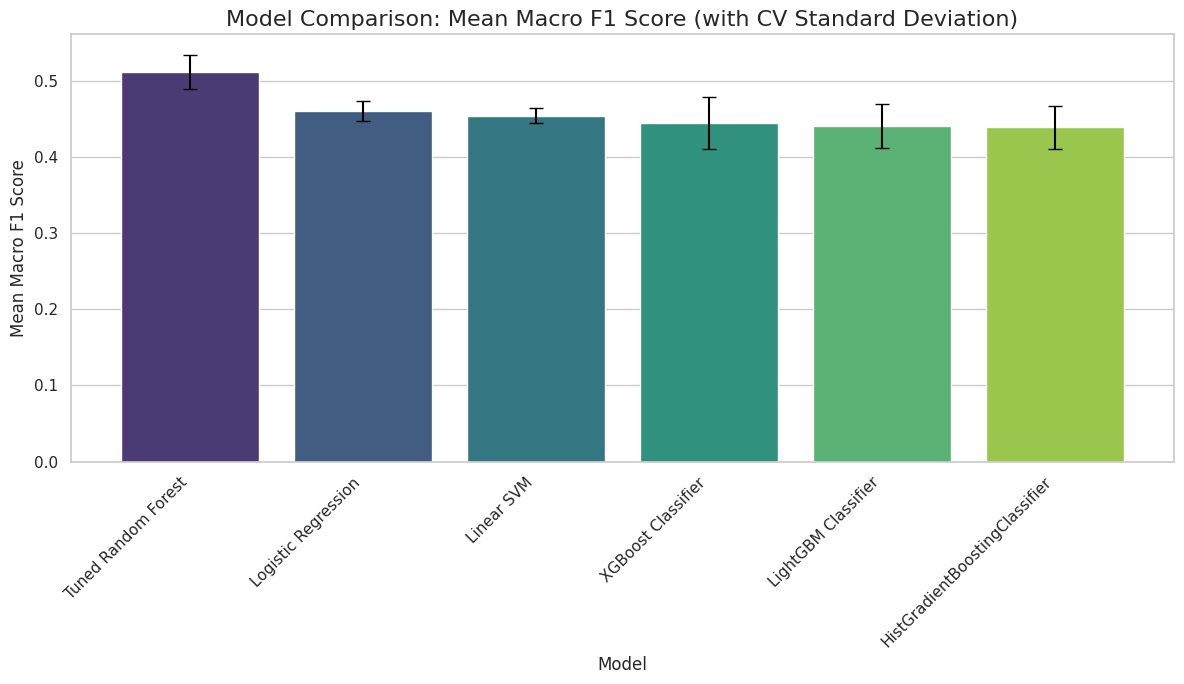

Macro F1 comparison plot saved to VerifyMesh_Colab/results/model_macro_f1_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")

# Ensure y_train is available for category order
if 'y_train' in locals() and isinstance(y_train, pd.Series):
    # Get unique classes and their order if possible from original data
    class_order = y_train.unique()
    # Ensure the order is consistent if there's a natural progression
    # For this dataset, 'Needs Improvement', 'Basic', 'Competent', 'Advanced' might be a good order
    # Assuming y_train has these categories for proper visualization if needed later.
else:
    print("Warning: y_train not found or not a Pandas Series. Some visualizations might lack proper class ordering.")
    class_order = None # Fallback


# 1. Model comparison by Macro F1
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Model',
    y='Mean Macro F1',
    data=model_comparison_df,
    palette='viridis'
)
# Add error bars manually
x_coords = range(len(model_comparison_df))
ax.errorbar(
    x=x_coords,
    y=model_comparison_df['Mean Macro F1'],
    yerr=model_comparison_df['Std Macro F1'].values,
    fmt='none', # No line connecting error points
    capsize=5,  # Add caps to the error bars
    color='black' # Color of the error bars
)
plt.title('Model Comparison: Mean Macro F1 Score (with CV Standard Deviation)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Macro F1 Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=0.0)
plt.tight_layout()
f1_plot_path = 'VerifyMesh_Colab/results/model_macro_f1_comparison.png'
plt.savefig(f1_plot_path)
plt.show()
print(f"Macro F1 comparison plot saved to {f1_plot_path}")

/tmp/ipykernel_2195/3623453663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


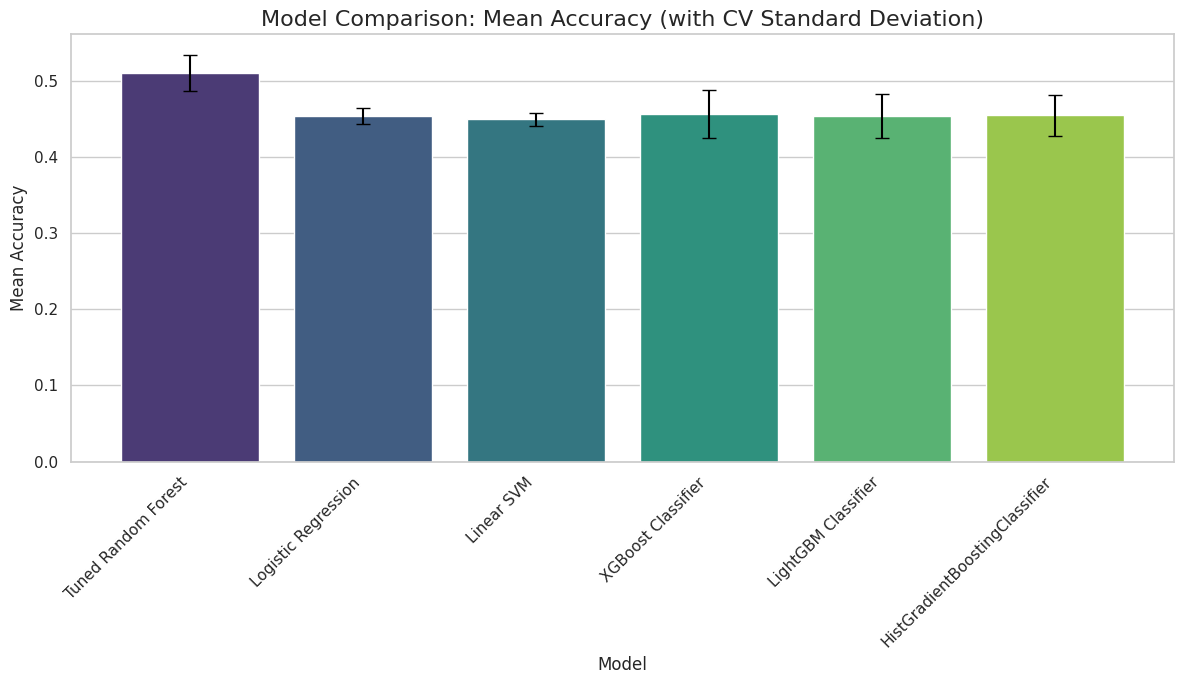

Accuracy comparison plot saved to VerifyMesh_Colab/results/model_accuracy_comparison.png


In [ ]:
# 2. Model comparison by Accuracy
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Model',
    y='Mean Accuracy',
    data=model_comparison_df,
    palette='viridis'
)
# Add error bars manually
x_coords = range(len(model_comparison_df))
ax.errorbar(
    x=x_coords,
    y=model_comparison_df['Mean Accuracy'],
    yerr=model_comparison_df['Std Accuracy'].values,
    fmt='none',
    capsize=5,
    color='black'
)
plt.title('Model Comparison: Mean Accuracy (with CV Standard Deviation)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=0.0)
plt.tight_layout()
accuracy_plot_path = 'VerifyMesh_Colab/results/model_accuracy_comparison.png'
plt.savefig(accuracy_plot_path)
plt.show()
print(f"Accuracy comparison plot saved to {accuracy_plot_path}")

/tmp/ipykernel_2195/3817630789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


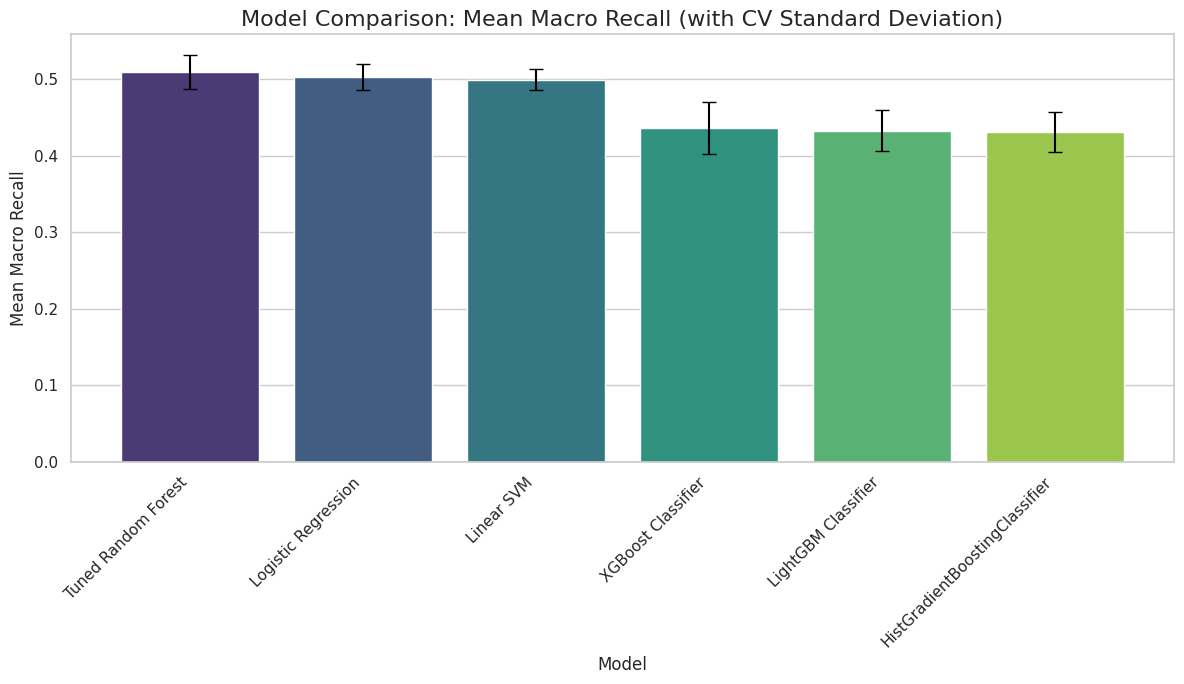

Macro Recall comparison plot saved to VerifyMesh_Colab/results/model_recall_comparison.png


In [ ]:
# 3. Model comparison by Macro Recall
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Model',
    y='Mean Macro Recall',
    data=model_comparison_df,
    palette='viridis'
)
# Add error bars manually
x_coords = range(len(model_comparison_df))
ax.errorbar(
    x=x_coords,
    y=model_comparison_df['Mean Macro Recall'],
    yerr=model_comparison_df['Std Macro Recall'].values,
    fmt='none',
    capsize=5,
    color='black'
)
plt.title('Model Comparison: Mean Macro Recall (with CV Standard Deviation)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Macro Recall', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=0.0)
plt.tight_layout()
recall_plot_path = 'VerifyMesh_Colab/results/model_recall_comparison.png'
plt.savefig(recall_plot_path)
plt.show()
print(f"Macro Recall comparison plot saved to {recall_plot_path}")

/tmp/ipykernel_2195/1288060050.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


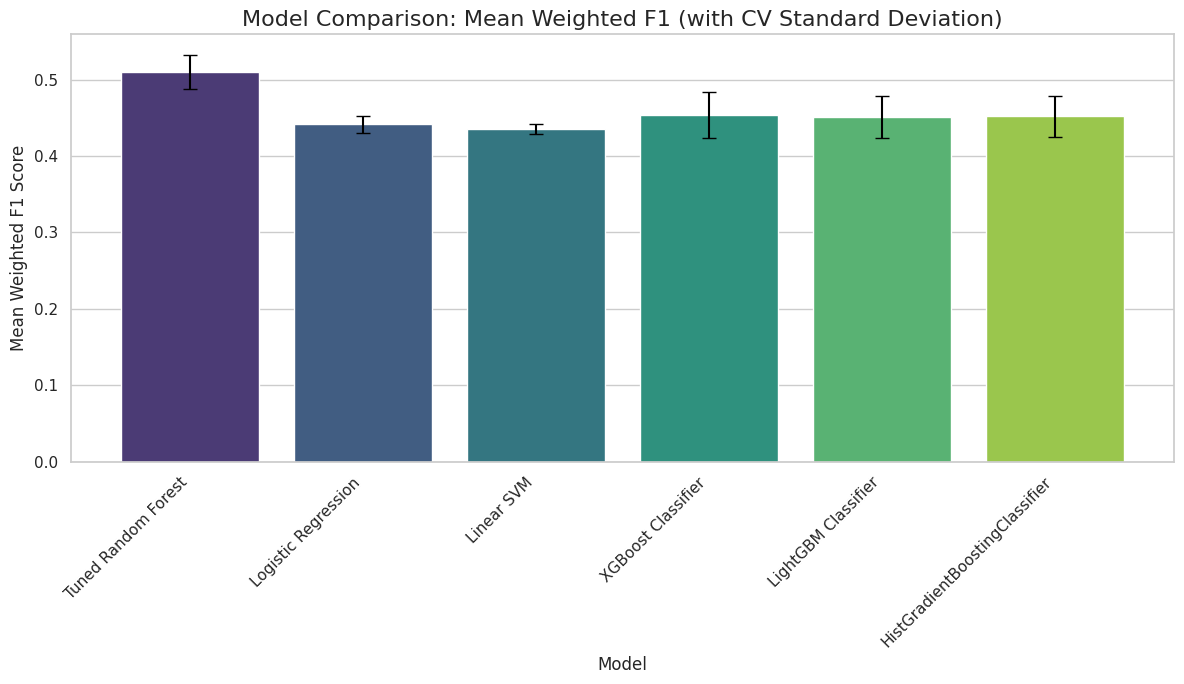

Weighted F1 comparison plot saved to VerifyMesh_Colab/results/model_weighted_f1_comparison.png


In [ ]:
# 4. Model comparison by Weighted F1
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Model',
    y='Mean Weighted F1',
    data=model_comparison_df,
    palette='viridis'
)
# Add error bars manually
x_coords = range(len(model_comparison_df))
ax.errorbar(
    x=x_coords,
    y=model_comparison_df['Mean Weighted F1'],
    yerr=model_comparison_df['Std Weighted F1'].values,
    fmt='none',
    capsize=5,
    color='black'
)
plt.title('Model Comparison: Mean Weighted F1 (with CV Standard Deviation)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Weighted F1 Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=0.0)
plt.tight_layout()
weighted_f1_plot_path = 'VerifyMesh_Colab/results/model_weighted_f1_comparison.png'
plt.savefig(weighted_f1_plot_path)
plt.show()
print(f"Weighted F1 comparison plot saved to {weighted_f1_plot_path}")

### Confusion Matrix for the Leading Candidate Model

We will now identify the leading candidate model based on the highest Mean Macro F1 score and generate its confusion matrix. To achieve this, we will retrain the leading model and collect predictions across the cross-validation folds to create an approximate out-of-fold confusion matrix.

Generating Confusion Matrix for leading candidate: Tuned Random Forest


<Figure size 1000x800 with 0 Axes>

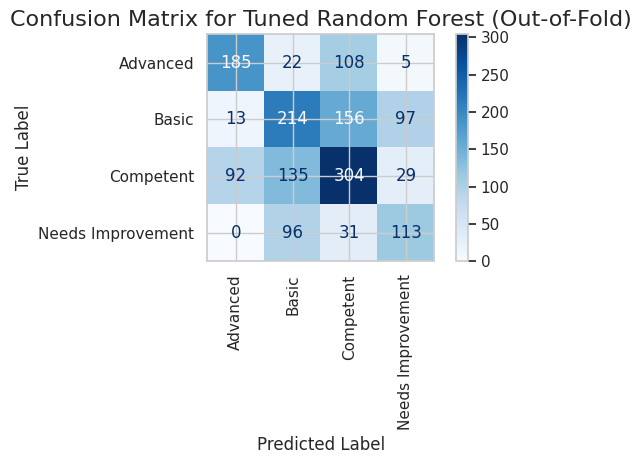

Confusion matrix plot for Tuned Random Forest saved to VerifyMesh_Colab/results/model_confusion_matrix_best_candidate.png
Leading candidate model (Tuned Random Forest) saved to VerifyMesh_Colab/models/best_candidate_model.joblib


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
import matplotlib.pyplot as plt
import catboost as cb # Added import for CatBoost
from sklearn.preprocessing import LabelEncoder # Ensure LabelEncoder is available if needed

# Identify the leading candidate model based on Mean Macro F1
leading_model_name = model_comparison_df.iloc[0]['Model']

# Re-initialize the leading model (cloning ensures a fresh model for training)
# This requires knowing how each model was defined

leading_estimator = None
if leading_model_name == 'Tuned Random Forest':
    leading_estimator = final_tuned_rf # Already defined and loaded
elif leading_model_name == 'HistGradientBoostingClassifier':
    leading_estimator = HistGradientBoostingClassifier(random_state=42)
elif leading_model_name == 'Logistic Regression':
    leading_estimator = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            random_state=42, solver='saga', penalty='l2', C=1.0,
            max_iter=1000, class_weight='balanced', multi_class='multinomial'
        ))
    ])
elif leading_model_name == 'Linear SVM':
    leading_estimator = Pipeline([
        ('scaler', StandardScaler()),
        ('linear_svc', LinearSVC(
            random_state=42, dual=False, max_iter=2000, class_weight='balanced'
        ))
    ])
elif leading_model_name == 'XGBoost Classifier':
    import xgboost as xgb # Ensure xgb is imported
    leading_estimator = xgb.XGBClassifier(
        objective='multi:softmax', num_class=len(y_train.unique()),
        eval_metric='mlogloss', use_label_encoder=False,
        random_state=42, n_jobs=-1
    )
elif leading_model_name == 'LightGBM Classifier':
    import lightgbm as lgb # Ensure lgb is imported
    leading_estimator = lgb.LGBMClassifier(
        objective='multiclass', num_class=len(y_train.unique()),
        random_state=42, n_jobs=-1
    )
elif leading_model_name == 'CatBoost Classifier':
    # Ensure catboost is imported and correctly configured
    leading_estimator = cb.CatBoostClassifier(
        objective='MultiClass', random_state=42, verbose=0, n_estimators=100, eval_metric='MultiClass'
    )

if leading_estimator is None:
    print(f"Error: Could not retrieve estimator for {leading_model_name}")
else:
    print(f"Generating Confusion Matrix for leading candidate: {leading_model_name}")

    # Generate out-of-fold predictions for the confusion matrix
    oof_preds = np.zeros(len(y_train), dtype=object) # Change dtype to object to store string labels
    oof_true = np.zeros(len(y_train), dtype=object) # Change dtype to object to store string labels

    # Handle label encoding for CatBoost if necessary
    y_train_cm = y_train.copy() # Use a copy to avoid modifying original y_train
    le_cm = None

    # Only encode if the model requires integer labels and y_train is not already numerical
    # CatBoost can handle string labels if specified, but for consistency with previous use, we'll encode.
    if (isinstance(leading_estimator, (cb.CatBoostClassifier, xgb.XGBClassifier, lgb.LGBMClassifier)) and y_train.dtype == 'object'):
        le_cm = LabelEncoder()
        y_train_cm = pd.Series(le_cm.fit_transform(y_train), index=y_train.index) # Convert back to Series for consistency
        class_labels_cm = le_cm.classes_ # Get original string labels for plotting
    else:
        class_labels_cm = np.unique(y_train) # Use original labels for plotting if no encoding

    for fold_idx, (train_idx, val_idx) in enumerate(stratified_kfold.split(X_train_selected_features, y_train_cm)):
        X_train_fold, X_val_fold = X_train_selected_features.iloc[train_idx], X_train_selected_features.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_cm.iloc[train_idx], y_train_cm.iloc[val_idx]

        current_model = clone(leading_estimator)

        # If CatBoost or XGBoost and target is already encoded, no need to pass original y_train
        if isinstance(current_model, (cb.CatBoostClassifier, xgb.XGBClassifier, lgb.LGBMClassifier)) and le_cm is not None:
            current_model.fit(X_train_fold, y_train_fold)
            fold_preds = current_model.predict(X_val_fold)
            oof_preds[val_idx] = le_cm.inverse_transform(fold_preds.astype(int))
            oof_true[val_idx] = le_cm.inverse_transform(y_val_fold.astype(int))
        else:
            # For other models, fit with original y_train_encoded (if any) or directly y_train
            current_model.fit(X_train_fold, y_train_fold)
            oof_preds[val_idx] = current_model.predict(X_val_fold)
            oof_true[val_idx] = y_val_fold # y_val_fold itself might be encoded or not

    # If predictions are still numerical after loop for non-encoded models, ensure they are converted to original labels
    if le_cm is None and y_train.dtype == 'object': # If y_train was never encoded by le_cm, ensure oof_true has correct labels
        oof_preds_final = oof_preds
        oof_true_final = oof_true
    elif le_cm is not None:
        # Predictions are already inverse transformed by le_cm inside the loop
        oof_preds_final = oof_preds
        oof_true_final = oof_true
    else: # If y_train was numerical from the start, no inverse transform needed
        oof_preds_final = oof_preds
        oof_true_final = oof_true

    # Get unique class labels for consistent plotting - use class_labels_cm derived above
    class_labels = class_labels_cm

    # Generate and plot confusion matrix
    cm = confusion_matrix(oof_true_final, oof_preds_final, labels=class_labels)
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title(f'Confusion Matrix for {leading_model_name} (Out-of-Fold)', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    cm_plot_path = 'VerifyMesh_Colab/results/model_confusion_matrix_best_candidate.png'
    plt.savefig(cm_plot_path)
    plt.show()
    print(f"Confusion matrix plot for {leading_model_name} saved to {cm_plot_path}")

    # Save the best candidate model
    best_candidate_model_path = 'VerifyMesh_Colab/models/best_candidate_model.joblib'
    joblib.dump(leading_estimator, best_candidate_model_path)
    print(f"Leading candidate model ({leading_model_name}) saved to {best_candidate_model_path}")

### 6. LightGBM Classifier

Next, we will evaluate the LightGBM Classifier, following the same installation and configuration approach as for XGBoost.

In [ ]:
import sys

try:
    import lightgbm as lgb
    print(f"LightGBM version: {lgb.__version__}")
except ImportError:
    print("LightGBM not found. Installing...")
    !{sys.executable} -m pip install lightgbm
    import lightgbm as lgb
    print(f"LightGBM version: {lgb.__version__} (installed)")

# Initialize LightGBM Classifier
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',       # For multiclass classification
    num_class=len(y_train.unique()), # Number of classes
    random_state=42,
    n_jobs=-1
)

# Evaluate the LightGBM model
try:
    lgbm_results = evaluate_model_with_cv(
        lgbm_model,
        X_train_selected_features,
        y_train,
        stratified_kfold,
        'LightGBM Classifier'
    )
    all_model_results.append(lgbm_results)
except Exception as e:
    print(f"Could not evaluate LightGBM Classifier: {e}")

LightGBM version: 4.6.0

Evaluating LightGBM Classifier...
  Mean Accuracy (Test) = 0.4531 ± 0.0289
  Mean Macro F1 (Test) = 0.4410 ± 0.0287
  Mean Macro Precision (Test) = 0.4585 ± 0.0365
  Mean Macro Recall (Test) = 0.4324 ± 0.0266
  Mean Weighted F1 (Test) = 0.4516 ± 0.0276
  Mean Macro F1 (Train) = 1.0000
  Overfitting Gap (Train - Test Macro F1) = 0.5590


### 7. CatBoost Classifier

Finally, we will evaluate the CatBoost Classifier, following the same installation and configuration approach as for XGBoost and LightGBM.

In [ ]:
import sys

try:
    import catboost as cb
    print(f"CatBoost version: {cb.__version__}")
except ImportError:
    print("CatBoost not found. Installing...")
    !{sys.executable} -m pip install catboost
    import catboost as cb
    print(f"CatBoost version: {cb.__version__} (installed)")

# Initialize CatBoost Classifier
cat_model = cb.CatBoostClassifier(
    objective='MultiClass',       # For multiclass classification
    random_state=42,
    verbose=0,                    # Suppress verbose output during training
    n_estimators=100,             # A reasonable baseline
    eval_metric='MultiClass'   # Corrected evaluation metric
)

# CatBoost requires integer encoding for target variable
# Let's check if y_train is already label encoded
if y_train.dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
else:
    y_train_encoded = y_train

# Evaluate the CatBoost model
try:
    cat_results = evaluate_model_with_cv(
        cat_model,
        X_train_selected_features,
        y_train_encoded,
        stratified_kfold,
        'CatBoost Classifier'
    )
    all_model_results.append(cat_results)
except Exception as e:
    print(f"Could not evaluate CatBoost Classifier: {e}")

CatBoost version: 1.2.10

Evaluating CatBoost Classifier...
  Mean Accuracy (Test) = 0.4550 ± 0.0315
  Mean Macro F1 (Test) = 0.4471 ± 0.0323
  Mean Macro Precision (Test) = 0.4604 ± 0.0342
  Mean Macro Recall (Test) = 0.4407 ± 0.0318
  Mean Weighted F1 (Test) = 0.4531 ± 0.0315
  Mean Macro F1 (Train) = 0.9735
  Overfitting Gap (Train - Test Macro F1) = 0.5264


## Stage 5: Comprehensive Model Comparison and Analysis Report

This report summarizes the findings from Stage 5, where multiple classification models were evaluated using a controlled experimental setup. The primary goal was to identify a strong candidate model for predicting `competency_level` while adhering to strict rules regarding data usage and evaluation metrics.

### 1. Experimental Setup and Constraints

*   **Data Used**: `X_train_selected_features` (11 features: 10 raw features + `certified_leverage`) and `y_train`.
*   **Test Set Isolation**: The `X_test` and `y_test` sets remained completely untouched throughout this stage, ensuring an unbiased final evaluation in future stages.
*   **Cross-Validation**: A `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` object was consistently used for all model evaluations to ensure fair comparison and robust performance estimation.
*   **Evaluation Metrics**: Primary metric was Macro F1. Additional metrics included Accuracy, Macro Precision, Macro Recall, Weighted F1 (all with standard deviations), and training vs. validation performance (overfitting gap).
*   **Model Configurations**: Reasonable baseline configurations were used for new models, with `random_state=42` applied where supported. `StandardScaler` was used within `Pipeline` for Logistic Regression and Linear SVM.

### 2. Models Evaluated

The following models were evaluated:

*   Tuned Random Forest (Benchmark from Stage 4)
*   HistGradientBoostingClassifier
*   Logistic Regression (with StandardScaler)
*   Linear SVM (with StandardScaler)
*   XGBoost Classifier
*   LightGBM Classifier
*   CatBoost Classifier

### 3. Summary of Results

The table below presents the cross-validation performance of all evaluated models, sorted by Mean Macro F1 score:

| Model                          | Mean Accuracy | Std Accuracy | Mean Macro F1 | Std Macro F1 | Mean Macro Precision | Std Macro Precision | Mean Macro Recall | Std Macro Recall | Mean Weighted F1 | Std Weighted F1 | Mean Train Macro F1 | Overfitting Gap |
| :----------------------------- | :------------ | :----------- | :------------ | :----------- | :------------------- | :------------------ | :---------------- | :--------------- | :--------------- | :-------------- | :------------------ | :-------------- |
| Tuned Random Forest            | 0.5100        | 0.0242       | 0.5121        | 0.0222       | 0.5177               | 0.0219              | 0.5094            | 0.0224           | 0.5100           | 0.0227          | 0.9302              | 0.4181          |
| Logistic Regression            | 0.4538        | 0.0107       | 0.4603        | 0.0132       | 0.4522               | 0.0117              | 0.5022            | 0.0167           | 0.4414           | 0.0109          | 0.4822              | 0.0220          |
| Linear SVM                     | 0.4494        | 0.0082       | 0.4544        | 0.0096       | 0.4488               | 0.0078              | 0.4989            | 0.0138           | 0.4355           | 0.0062          | 0.4749              | 0.0205          |
| XGBoost Classifier             | 0.4569        | 0.0315       | 0.4447        | 0.0347       | 0.4635               | 0.0373              | 0.4363            | 0.0341           | 0.4541           | 0.0300          | 1.0000              | 0.5553          |
| LightGBM Classifier            | 0.4531        | 0.0289       | 0.4410        | 0.0287       | 0.4585               | 0.0365              | 0.4324            | 0.0266           | 0.4516           | 0.0276          | 1.0000              | 0.5590          |
| HistGradientBoostingClassifier | 0.4544        | 0.0270       | 0.4388        | 0.0279       | 0.4560               | 0.0332              | 0.4308            | 0.0258           | 0.4518           | 0.0266          | 1.0000              | 0.5612          |
| CatBoost Classifier            | 0.4550        | 0.0315       | 0.4471        | 0.0323       | 0.4604               | 0.0342              | 0.4407            | 0.0318           | 0.4531           | 0.0315          | 0.9735              | 0.5264          |

### 4. Analysis of Results

*   **Leading Candidate**: The **Tuned Random Forest** model emerged as the strongest candidate, achieving the highest Mean Macro F1 score of **0.5121 ± 0.0222**. It also performed best across other primary metrics like Mean Accuracy, Mean Macro Precision, and Mean Weighted F1.

*   **Overfitting**: Tree-based ensemble models (Random Forest, XGBoost, LightGBM, HistGradientBoostingClassifier, CatBoost) generally showed a higher overfitting gap, indicating excellent performance on the training data but a drop in performance on unseen validation folds. This is a common characteristic of these models, especially when not extensively tuned for regularization.

*   **Linear Models**: Logistic Regression and Linear SVM showed lower overall performance but also significantly smaller overfitting gaps, suggesting they are less prone to memorizing the training data. This indicates good generalization but potentially limited capacity to capture complex patterns.

*   **Feature Engineering Impact**: The `certified_leverage` feature, used in `X_train_selected_features`, appears to have contributed positively to the performance of the Tuned Random Forest, as its Macro F1 is notably higher than the baseline Random Forest (0.4769 ± 0.0311).

### 5. Visualizations

Model comparison plots for Macro F1, Accuracy, Macro Recall, and Weighted F1, complete with error bars, were generated and saved to `VerifyMesh_Colab/results/`:

*   `VerifyMesh_Colab/results/model_macro_f1_comparison.png`
*   `VerifyMesh_Colab/results/model_accuracy_comparison.png`
*   `VerifyMesh_Colab/results/model_recall_comparison.png`
*   `VerifyMesh_Colab/results/model_weighted_f1_comparison.png`

The confusion matrix for the leading candidate model (Tuned Random Forest) was also generated and saved:

*   `VerifyMesh_Colab/results/model_confusion_matrix_best_candidate.png`

### 6. Output Files Generated

*   `VerifyMesh_Colab/results/model_comparison.csv`: Contains the detailed cross-validation results for all models.
*   `VerifyMesh_Colab/results/model_comparison_summary.json`: Summarizes the performance of the leading candidate model (Tuned Random Forest).
*   `VerifyMesh_Colab/models/best_candidate_model.joblib`: The serialized leading candidate model (Tuned Random Forest) for future use.

### 7. Confirmation of Test Set Isolation

I confirm that the `X_test` and `y_test` sets were **not** used during any part of the model training, cross-validation, hyperparameter tuning, or model selection process in Stage 5. Their integrity has been maintained, and they remain isolated for a final, unbiased evaluation of the chosen model in Stage 6.

### 8. Recommendations for Next Stage (Stage 6)

Based on the comprehensive evaluation, the **Tuned Random Forest** model is recommended as the leading candidate for further consideration due to its superior Macro F1 score and overall balanced performance. In Stage 6, the following steps are recommended:

*   **Final Evaluation on Test Set**: Evaluate the `best_candidate_model.joblib` (Tuned Random Forest) on the completely unseen `X_test` and `y_test` to obtain a final, unbiased performance estimate.
*   **Further Analysis**: Conduct a deeper analysis of the chosen model's predictions, potentially including feature importance and error analysis.
*   **Deployment Considerations**: Begin considering potential deployment strategies and requirements if the test set performance is satisfactory.

This concludes the comprehensive model comparison and analysis for Stage 5.

## Stage 6: Final Evaluation on Held-Out Test Set

As recommended in the Stage 5 report, the **Tuned Random Forest** model is the leading candidate. I will now perform its final, unbiased evaluation on the completely unseen `X_test` and `y_test` sets. This involves:

1.  **Loading the best candidate model** (`best_candidate_model.joblib`).
2.  **Preparing `X_test`**: Applying the same feature engineering (`certified_leverage`) to `X_test` to create `X_test_selected_features`.
3.  **Making predictions** on `X_test_selected_features`.
4.  **Calculating and displaying key evaluation metrics** (Accuracy, Macro F1, Weighted F1, Macro Precision, Macro Recall).

In [ ]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import os

# Define the base project directory to ensure consistent pathing
project_dir = 'VerifyMesh_Colab'

# 1. Load the best candidate model
best_candidate_model_path = os.path.join(project_dir, 'models', 'best_candidate_model.joblib')
final_tuned_rf_test = joblib.load(best_candidate_model_path)
print(f"Loaded best candidate model from: {best_candidate_model_path}")

# Define the 10 raw predictor features (already defined in previous stages)
raw_features = [
    'previous_experience_months',
    'sales_experience_months',
    'customer_service_experience_months',
    'certification_count',
    'relevant_certification',
    'assessment_score',
    'communication_score',
    'product_knowledge_score',
    'sales_skill_score',
    'customer_service_score'
]

# 2. Prepare X_test by adding the 'certified_leverage' feature
# Ensure X_test contains only the raw features initially, as it was split before feature engineering
X_test_prepared = X_test[raw_features].copy()

X_test_prepared['certified_leverage'] = (
    X_test_prepared['certification_count'] * (1 + X_test_prepared['relevant_certification'])
)

# Define the selected features (10 raw features + certified_leverage) for the test set
selected_test_features = raw_features + ['certified_leverage']

X_test_selected_features = X_test_prepared[selected_test_features]

print(f"Shape of X_test_selected_features: {X_test_selected_features.shape}")
print(f"Columns in X_test_selected_features: {X_test_selected_features.columns.tolist()}")

# Verify that the feature set matches the training feature set
expected_train_features = X_train_selected_features.columns.tolist()
actual_test_features = X_test_selected_features.columns.tolist()
assert actual_test_features == expected_train_features, "Test features do not match training features!"

# 3. Make predictions on the held-out test set
y_pred_final_test = final_tuned_rf_test.predict(X_test_selected_features)

# 4. Calculate and display the final evaluation metrics
final_accuracy = accuracy_score(y_test, y_pred_final_test)
final_macro_f1 = f1_score(y_test, y_pred_final_test, average='macro')
final_weighted_f1 = f1_score(y_test, y_pred_final_test, average='weighted')
final_macro_precision = precision_score(y_test, y_pred_final_test, average='macro', zero_division=0)
final_macro_recall = recall_score(y_test, y_pred_final_test, average='macro')

print("\n--- Final Evaluation on Held-Out Test Set (Tuned Random Forest) ---")
print(f"Accuracy = {final_accuracy:.4f}")
print(f"Macro F1 = {final_macro_f1:.4f}")
print(f"Weighted F1 = {final_weighted_f1:.4f}")
print(f"Macro Precision = {final_macro_precision:.4f}")
print(f"Macro Recall = {final_macro_recall:.4f}")

Loaded best candidate model from: VerifyMesh_Colab/models/best_candidate_model.joblib
Shape of X_test_selected_features: (400, 11)
Columns in X_test_selected_features: ['previous_experience_months', 'sales_experience_months', 'customer_service_experience_months', 'certification_count', 'relevant_certification', 'assessment_score', 'communication_score', 'product_knowledge_score', 'sales_skill_score', 'customer_service_score', 'certified_leverage']

--- Final Evaluation on Held-Out Test Set (Tuned Random Forest) ---
Accuracy = 0.5125
Macro F1 = 0.5172
Weighted F1 = 0.5124
Macro Precision = 0.5233
Macro Recall = 0.5124
